## <span style="color:green">Solutions</span>

In [8]:
import numpy as np
import netCDF4 as nc
from matplotlib import pyplot as plt
%matplotlib inline

winddata = nc.Dataset('/Users/Kroes027/Documents/PhD/Code/PythonCourse_IMAU_2024/PythonCourse_IMAU/data/DOWA_40h12tg2_fERA5_NETHERLANDS.NL_ix001_iy001_2018010100-2019010100_v1.0.nc')
longitude = winddata.variables['lon'][:]
latitude = winddata.variables['lat'][:]
time = winddata.variables['time'][:]

In [9]:
# 1. At what heights is the wind measured?
height = winddata.variables['height'][:]
print('The wind is measured at')
print(height)
print(winddata.variables['height'].units)
print('where positive is directed ' + winddata.variables['height'].positive)


The wind is measured at
[ 10.  20.  40.  60.  80. 100. 120. 140. 150. 160. 180. 200. 220. 250.
 300. 500. 600.]
m
where positive is directed up


Text(0, 0.5, 'wind speed [m s-1]')

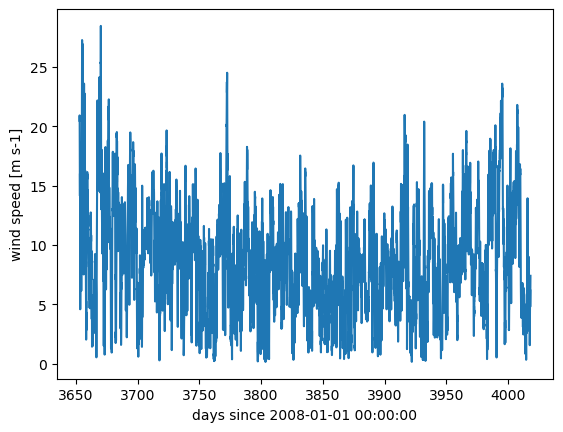

In [10]:
# 2. Plot the wind speed at 100 m as a function time. Add the units of time in the axis labels. 
# Hint: you may need to use the command np.squeeze
wspeed = np.squeeze(winddata.variables['wspeed'][:]) 
idz100 = height==100.

plt.plot(time,wspeed[:,idz100])
plt.xlabel(winddata.variables['time'].units)
plt.ylabel('wind speed ['+ winddata.variables['wspeed'].units+']')

Text(0, 0.5, 'wind direction [degree]')

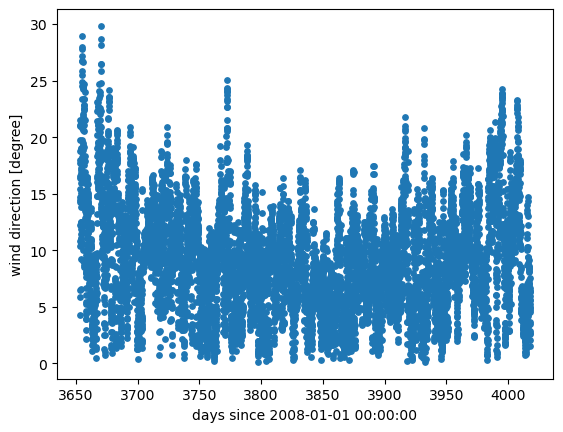

In [11]:
# 3. Create a scatter plot of the wind direction at 150 m height as a function of time.
wdir = np.squeeze(winddata.variables['wdir'][:]) 
idz150 = height==150.

plt.scatter(time,wspeed[:,idz150],15)
plt.xlabel(winddata.variables['time'].units)
plt.ylabel('wind direction ['+ winddata.variables['wdir'].units+']')


In [12]:
# 4. Print the time-averaged temperature at each height.
temp = np.squeeze(winddata.variables['ta'][:]) 
avg_temp_z = np.mean(temp,axis=1)

for ii in range(len(height)):
    print('At %.2f m, the average temperature is %.2f' %(height[ii],avg_temp_z[ii]))

At 10.00 m, the average temperature is 279.40
At 20.00 m, the average temperature is 281.00
At 40.00 m, the average temperature is 281.26
At 60.00 m, the average temperature is 281.27
At 80.00 m, the average temperature is 281.37
At 100.00 m, the average temperature is 281.50
At 120.00 m, the average temperature is 279.89
At 140.00 m, the average temperature is 280.26
At 150.00 m, the average temperature is 280.25
At 160.00 m, the average temperature is 279.79
At 180.00 m, the average temperature is 279.25
At 200.00 m, the average temperature is 278.52
At 220.00 m, the average temperature is 278.45
At 250.00 m, the average temperature is 278.71
At 300.00 m, the average temperature is 278.72
At 500.00 m, the average temperature is 278.56
At 600.00 m, the average temperature is 279.06


Text(0, 0.5, 'z [m]')

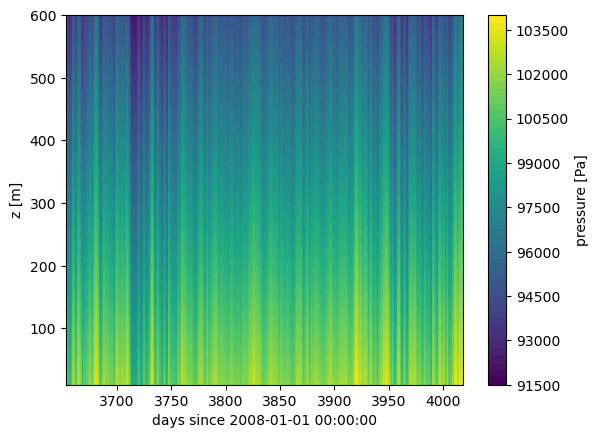

In [13]:
# 5. Create a contourplot of the pressure as a function of time and height.
press = np.squeeze(winddata.variables['p'][:]) 
[Tt,Zz] = np.meshgrid(height,time)

plt.contourf(Zz,Tt,press,50)
plt.colorbar(label='pressure ['+ winddata.variables['p'].units+']')
plt.xlabel(winddata.variables['time'].units)
plt.ylabel('z ['+ winddata.variables['height'].units+']')